<a href="https://colab.research.google.com/github/danielesivori/ROSE-PhD-Course-SHM-in-EE-2026/blob/main/Tutorial_2_EQ/Tutorial_2_EQ_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUTORIAL 1** - Output-only modal identification from ambient vibrations

## Introduction

We now analyse **seismic** recordings acquired from a permanent dynamic monitoring system on a 2-storey masonry building. Due to this seismic event (2016-10-30 06:40), which is part of the 2016 Central Italy earthquake sequence, the structure reached a moderate global damage level (DS2).

We will identify the modal parameters of the building from the codas of the earthquake and during the strong-motion response, and compare them with the pre-damage conditions (**Tutorial 1**).

To perform modal identification in presence of seismic excitation we will estimate of the frequency response function (FRF) of the system (input-output), comparing the results obtained in the codas with those provided by an output-only frequency-domain modal identification technique, the Frequency Domain Decomposition (FDD).

## Building \& data description (metadata)

The operational response of the structure has been recorded by two bi-axial FB accelerometers placed at each floor (L1, L2) whose channels are oriented along the two main directions of the building (X, Y). The sensors are also aligned vertically along the height of the building and placed roughly in its geometric center. Being the building symmetric in plan, this configuration can reliably capture horizontal translations but not torsion. The length of the recording is 60 s and the sampling rate is 250Hz.

Accelerations are reported in units of gravity (g), with samples organized in rows and channels in columns according to the following scheme:

COL1 COL2 COL3 COL4 COL5 COL6 COL 7


L0_X L0_Y L0_Z L1_X L1_Y L2_X L2_Y

## Data loading

Lets start by loading the data, which is saved in a text file on a public GitHub repository (https://github.com/danielesivori/ROSE-PhD-Course-SHM-in-EE-2026).

In [3]:
import pandas as pd

# Construct the raw GitHub URL for the data file based on the user's provided link
data_url = 'https://raw.githubusercontent.com/danielesivori/ROSE-PhD-Course-SHM-in-EE-2026/main/Tutorial_2_EQ/Tutorial_2_EQ_data.txt'

# Load the data using pandas.read_csv, specifying space as a separator and no header
df = pd.read_csv(data_url, sep=r'\s+', header=None)
#df = pd.read_csv('Tutorial_2_EQ_data.txt', sep=r'\s+', header=None)

# Display the first few rows of the dataframe
print("Data loaded")
print(df.head())

Data loaded
          0         1         2         3         4         5         6
0 -0.000098 -0.000032 -0.001978 -0.000022 -0.000203  0.000151  0.000179
1 -0.000069 -0.000021 -0.002048 -0.000018 -0.000192 -0.000031  0.000228
2 -0.000074  0.000012 -0.002076  0.000016 -0.000164 -0.000008  0.000246
3 -0.000078  0.000018 -0.002059  0.000002 -0.000167  0.000009  0.000271
4 -0.000091 -0.000027 -0.002001  0.000016 -0.000171  0.000000  0.000244


The loaded data consists of 6 signals (columns) sampled over time. Let's visualize these signals to understand their time-domain behavior.

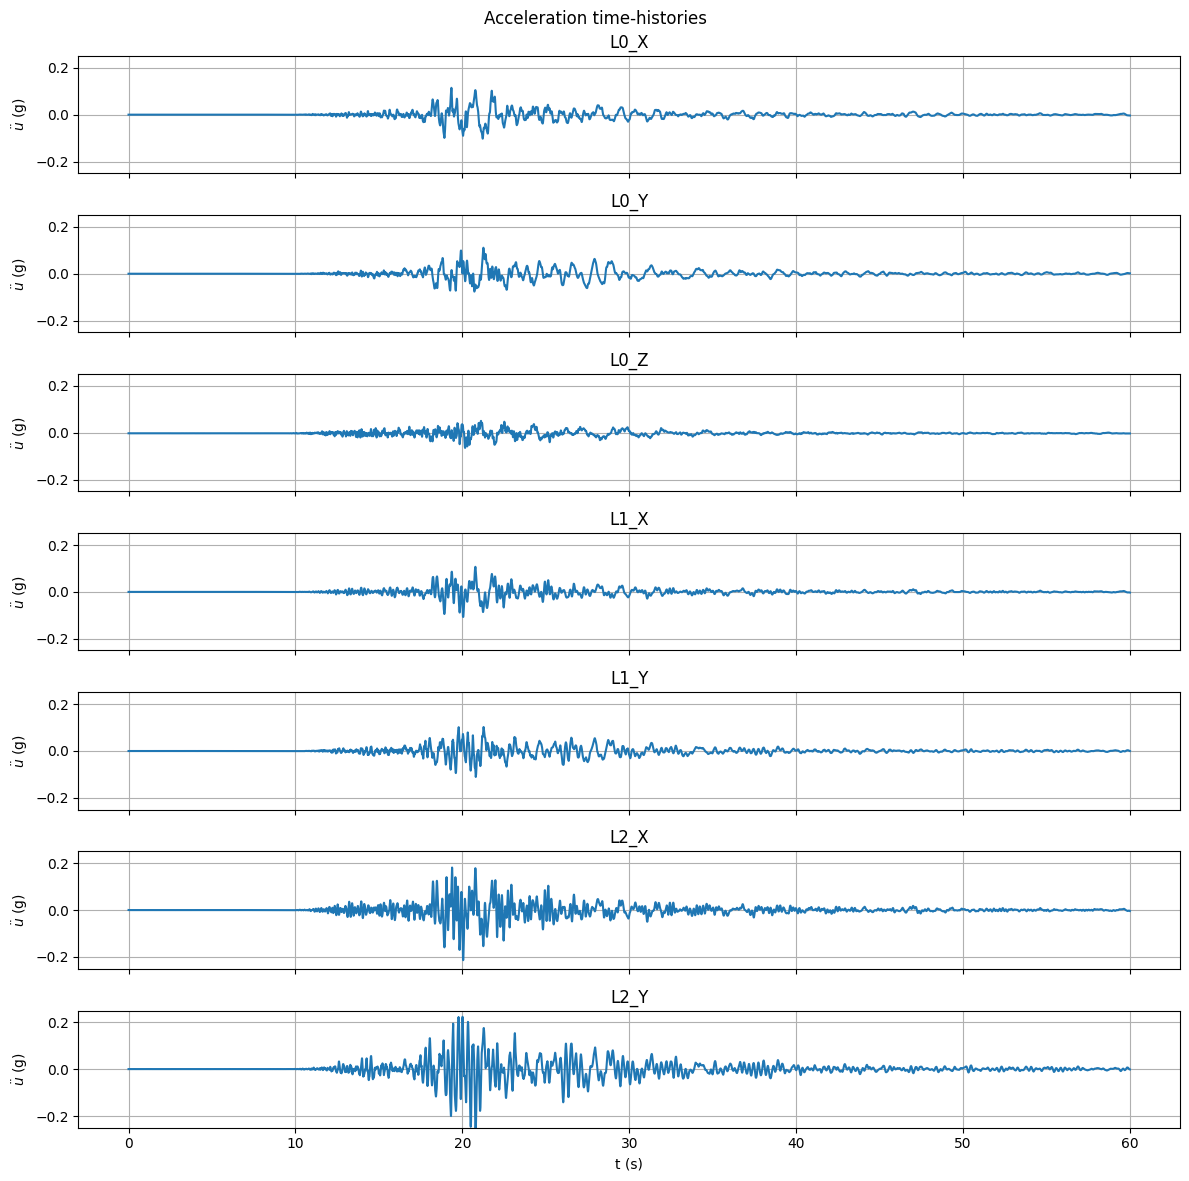

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# To numpy array
data = df.to_numpy()

fs = 250 # sampling frequency in Hz
Ts = 1/fs # sampling period in s
n = data.shape[0] # number of samples
N = data.shape[1] # number of channels
t = n / fs # length in seconds

# Time vector
time_v = np.arange(n) / fs

# Define channel names as per the problem description
channel_names = ['L0_X','L0_Y','L0_Z','L1_X', 'L1_Y', 'L2_X', 'L2_Y']

# Create a figure with subplots for each signal
fig, axes = plt.subplots(nrows=N, ncols=1, figsize=(12, 12), sharex=True)

# Plot each signal in its own subplot
for i in range(N):
    axes[i].plot(time_v, data[:, i], label=channel_names[i])
    axes[i].set_title(f'{channel_names[i]}')
    axes[i].set_ylabel(r'$\ddot{u}$ (g)')
    axes[i].grid(True)
    # axes[i].legend(loc='upper right')
    axes[i].set_ylim(-0.25,0.25)

# Set a common x-axis label for the bottom subplot
axes[-1].set_xlabel('t (s)')

plt.suptitle('Acceleration time-histories')
plt.tight_layout()
plt.show()

## Pre-processing - decimation & filtering

We perform an initial estimate of the **Power Spectral Density (PSD)** of the signals using the periodogram method to take a look at the frequency content and plan filtering and decimation before proceeding with the identification.

Using whole signal of length 60s (15000 samples) for an approximate frequency resolution of 0.017 Hz


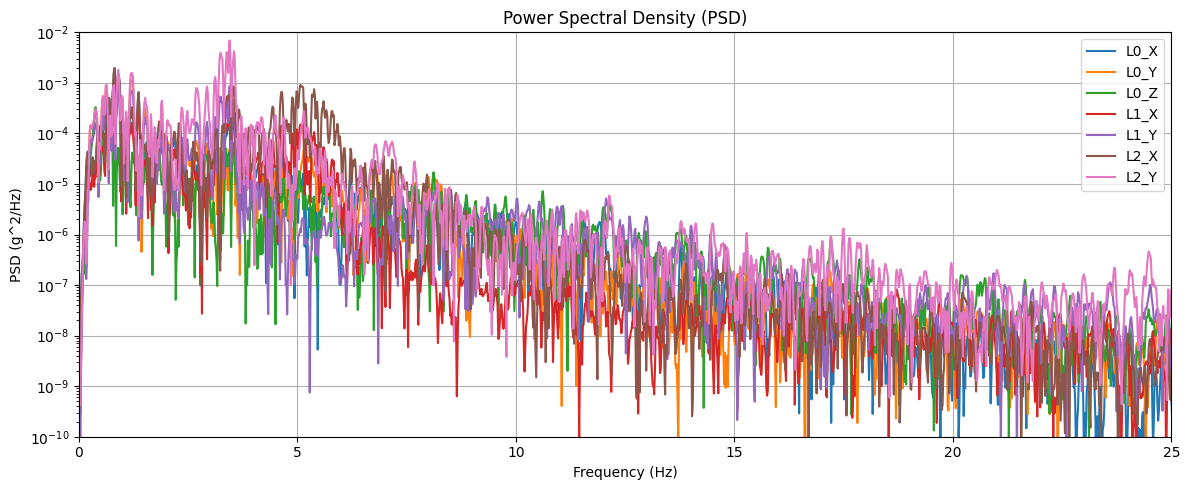

In [5]:
from scipy.signal import periodogram

# Parameters for periodogram
nperseg = n
seg_len = nperseg / fs

# Frequency resolution
df = 1/seg_len

print(f"Using whole signal of length {seg_len:.0f}s ({nperseg:.0f} samples) for an approximate frequency resolution of {1/seg_len:.3f} Hz")

# Single figure for all PSDs
plt.figure(figsize=(12, 5))

# Plot PSD for each channel
for i in range(N):

    # Periodogram with classic Hanning window
    fv, Pxx = periodogram(data[:, i], fs=fs, window='hann', scaling='density')

    # Plot
    plt.semilogy(fv, Pxx, label=channel_names[i]) # semilogy

plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (g^2/Hz)')
plt.grid(True)
plt.xlim(0,25)
plt.ylim(1e-10,1e-2)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Decimation

The main frequency content is in the range [0.1-10] Hz. Let's start by **decimating** the data by fixing the new Nyquist frequency to 25 Hz. Typically decimation function applies an **anti-aliasing low-pass filter** (Chebyshev type I in this case) before downsampling.

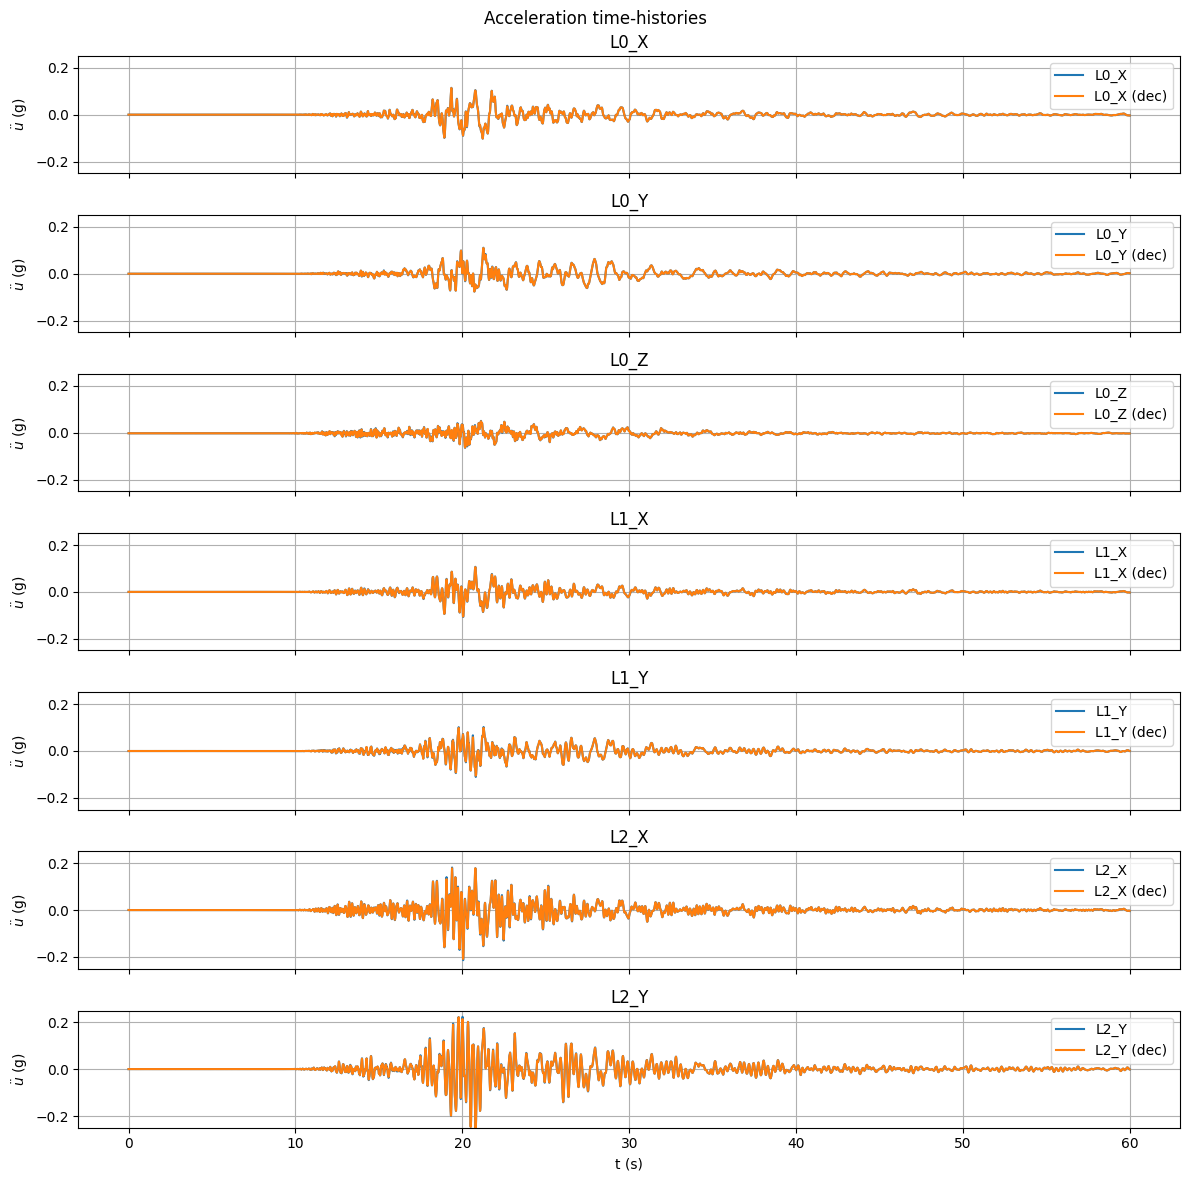

In [6]:
from scipy.signal import decimate

f_nyq_dec = 25 # desired Nyquist frequency after decimation (must be < fs/2)
dec_factor = fs // (2 * f_nyq_dec)  # decimation factor: 250 / (2*25) = 5
fs_dec = fs // dec_factor  # 50 Hz

# Decimate each channel (applies anti-aliasing filter internally)
data_dec = np.column_stack([decimate(data[:, i], dec_factor) for i in range(N)])

n_dec = data_dec.shape[0]
time_v_dec = np.arange(n_dec) / fs_dec

# Create a figure with subplots for each signal
fig, axes = plt.subplots(nrows=N, ncols=1, figsize=(12, 12), sharex=True)

# Plot each signal in its own subplot
for i in range(N):
    axes[i].plot(time_v, data[:, i], label=channel_names[i])
    axes[i].plot(time_v_dec, data_dec[:, i], label=f'{channel_names[i]} (dec)')
    axes[i].set_title(f'{channel_names[i]}')
    axes[i].set_ylabel(r'$\ddot{u}$ (g)')
    axes[i].grid(True)
    axes[i].legend(loc='upper right')
    axes[i].set_ylim(-0.25,0.25)

# Set a common x-axis label for the bottom subplot
axes[-1].set_xlabel('t (s)')

plt.suptitle('Acceleration time-histories')
plt.tight_layout()
plt.show()

We estimate the PSD again on the decimated signal:

Using whole signal of length 60s (3000 samples) for an approximate frequency resolution of 0.017 Hz


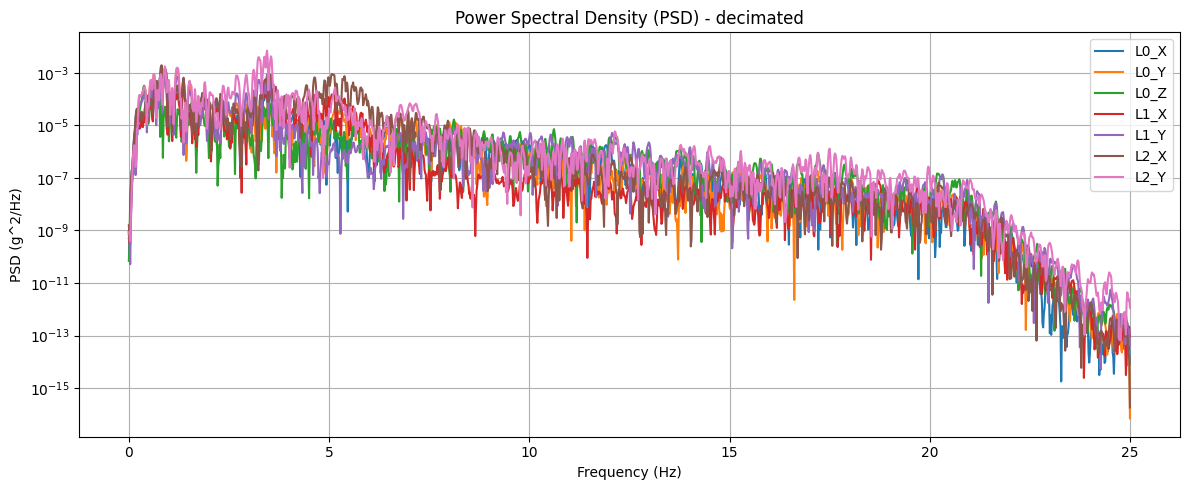

In [7]:
# Parameters for periodogram
nperseg = n_dec
seg_len = nperseg / fs_dec

# Frequency resolution
df = 1/seg_len

print(f"Using whole signal of length {seg_len:.0f}s ({nperseg:.0f} samples) for an approximate frequency resolution of {1/seg_len:.3f} Hz")

# Figure
plt.figure(figsize=(12, 5))

# Plot PSD for each channel
for i in range(N):

    # Periodogram with classic Hanning window
    fv, Pxx = periodogram(data_dec[:, i], fs=fs_dec, window='hann', scaling='density')

    # Plot
    plt.semilogy(fv, Pxx, label=channel_names[i]) # semilogy

plt.title('Power Spectral Density (PSD) - decimated')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (g^2/Hz)')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Filtering

There seeem to be no content at low frequency. Let's still apply a **high-pass filter** at 0.1 Hz (acausal, FIR or IIR). This will also remove potential **trends and offset** from zero-mean (DC component).

We can choose an **IIR Butterworth filter** (rather than FIR) for computational efficiency
and robustness. The zero-phase sosfiltfilt application ensures acausality (forward-backward
filtering), eliminating the phase distortion that would occur with a standard causal filter.

High-pass IIR Butterworth filter. Order: 6, cutoff: 0.1 Hz, fs: 50 Hz


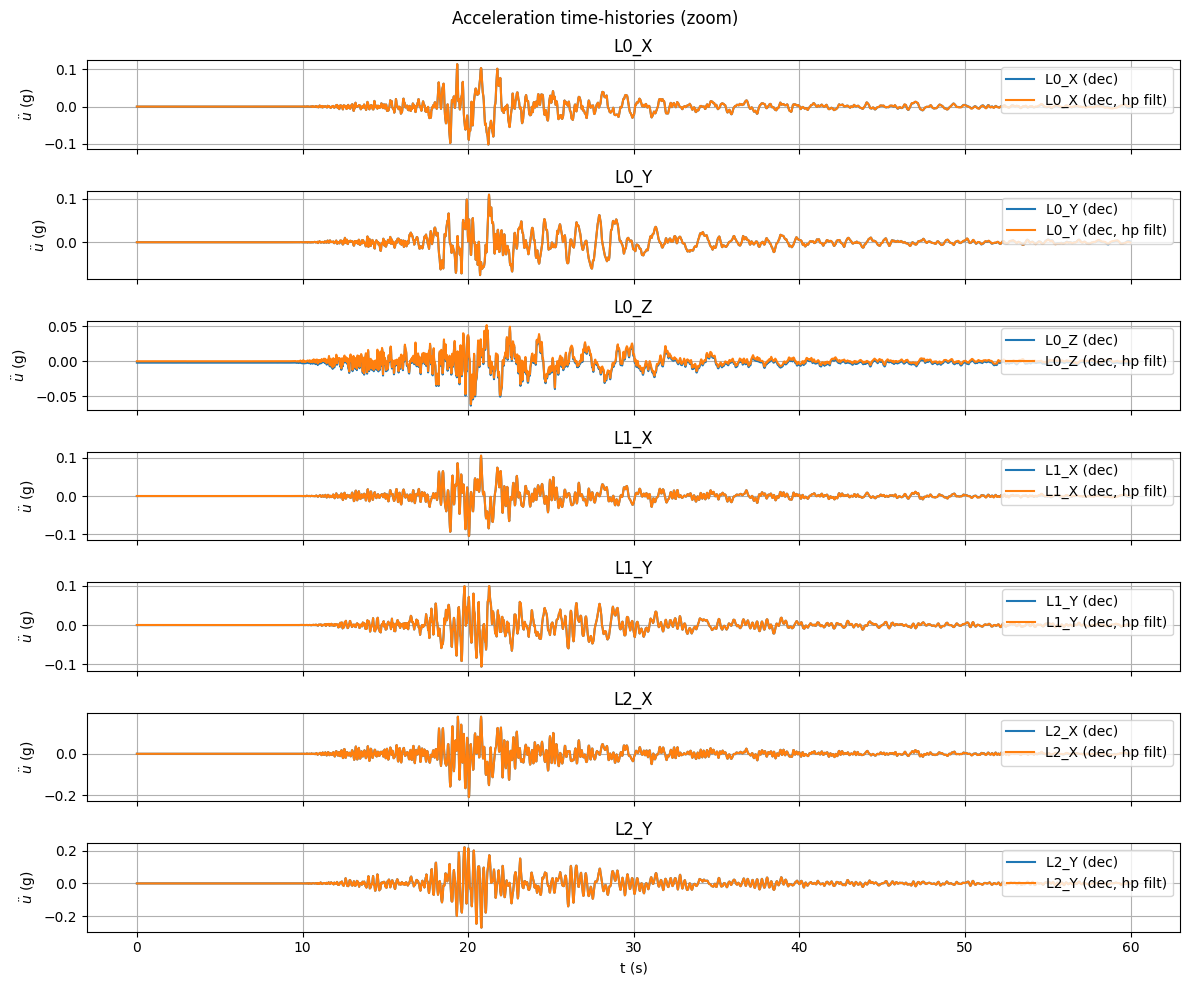

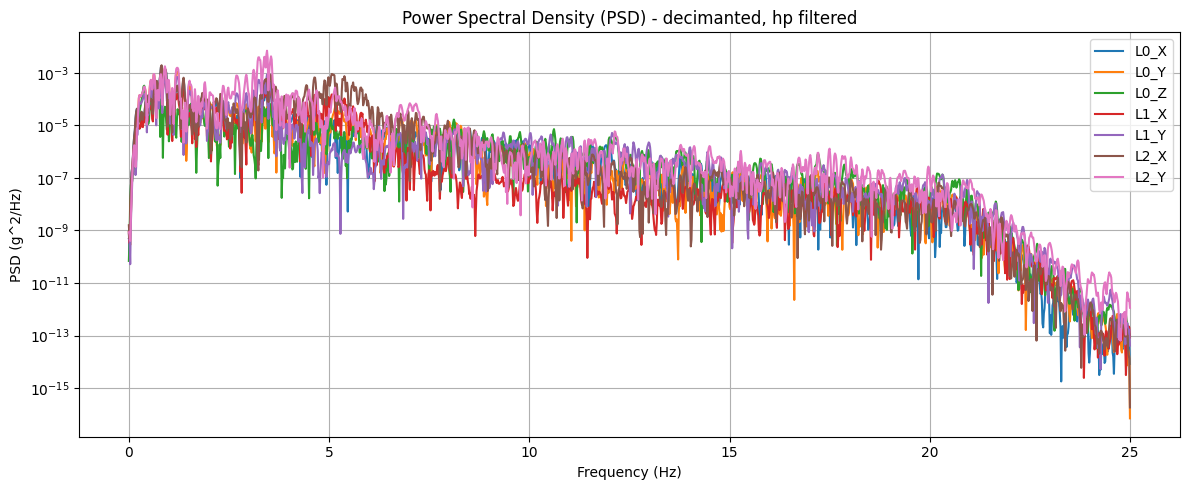

In [8]:
from scipy.signal import butter, sosfiltfilt

f_cutoff = 0.1     # Hz

# # FIR
# numtaps  = 501 # filter order + 1 (odd → symmetric, linear phase)
# # firwin designs low-pass by default; pass_zero=False → high-pass
# b = firwin(numtaps, f_cutoff, fs=fs_dec, pass_zero=False, window='hamming')
# # filtfilt: zero-phase forward-backward application (acausal)
# data_filt = np.column_stack([filtfilt(b, 1.0, data_dec[:, i]) for i in range(N)])
# print(f"High-pass FIR filter. Order: {numtaps - 1}, cutoff: {f_cutoff} Hz, fs: {fs_dec} Hz")

# IIR
order = 6 # same order of decimate
# sos: second-order sections
sos = butter(order, f_cutoff, btype='high', fs=fs_dec, output='sos')
# sosfiltfilt: zero-phase forward-backward application (acausal)
data_filt = np.column_stack([sosfiltfilt(sos, data_dec[:, i]) for i in range(N)])

print(f"High-pass IIR Butterworth filter. Order: {order}, cutoff: {f_cutoff} Hz, fs: {fs_dec} Hz")

# Figure
fig, axes = plt.subplots(nrows=N, ncols=1, figsize=(12, 10), sharex=True)

# Plot each signal in its own subplot
for i in range(N):
    axes[i].plot(time_v_dec, data_dec[:, i], label=f'{channel_names[i]} (dec)')
    axes[i].plot(time_v_dec, data_filt[:, i], label=f'{channel_names[i]} (dec, hp filt)')
    axes[i].set_title(f'{channel_names[i]}')
    axes[i].set_ylabel(r'$\ddot{u}$ (g)')
    axes[i].grid(True)
    axes[i].legend(loc='upper right')
    #axes[i].set_ylim(-0.0005,0.0005)
    #axes[i].set_xlim(272,278)

# Set a common x-axis label for the bottom subplot
axes[-1].set_xlabel('t (s)')

plt.suptitle('Acceleration time-histories (zoom)')
plt.tight_layout()
plt.show()

# Figure
plt.figure(figsize=(12, 5))

# Plot PSD for each channel
for i in range(N):

    # periodogram method with classic Hanning window
    fv, Pxx = periodogram(data_dec[:, i], fs=fs_dec, window='hann', scaling='density')

    # Plot
    plt.semilogy(fv, Pxx, label=channel_names[i]) # semilogy

plt.title('Power Spectral Density (PSD) - decimanted, hp filtered')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (g^2/Hz)')
#plt.ylim(1e-14,1e-9)
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Time-frequency analysis (spectrogram)

Before moving to the identification, it is instructive to look at the **time-frequency** content of the response. The seismic record is **non-stationary** from the frequency perspective: the modal frequencies are not constant in time but tend to **drop during the strong-motion** phase (because of increasing amplitude of oscillations, increased damping and stiffness degradation associated with damage) and to partially **recover in the coda**. A single global periodogram (used later for the FRF) only gives an *averaged* picture, while the **Short-Time Fourier Transform (STFT) spectrogram** resolves the frequency evolution along time

We look at the top-floor channels in **X** (`L2_X`) and **Y** (`L2_Y`), where the modal content is most energetic.

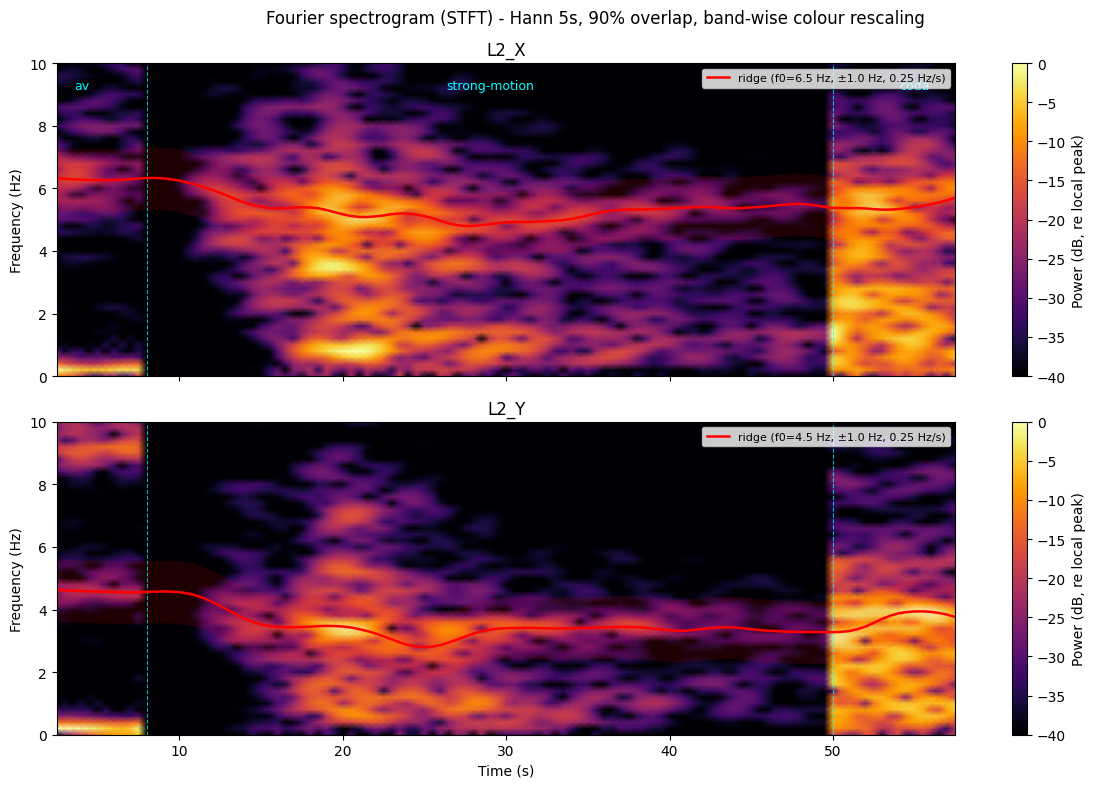

In [9]:
from scipy.signal import spectrogram, medfilt, savgol_filter

# Short-Time Fourier Transform (STFT) spectrogram: time-frequency analysis

#   - short window  -> good time resolution, coarse frequency resolution
#   - long window   -> good frequency resolution, coarse time resolution

# Hann window of ~5 s with 90% overlap

win_sec    = 5.0                             # window length (s)
nperseg_s  = int(win_sec * fs_dec)           # samples per window
noverlap_s = int(0.9 * nperseg_s)            # 90% overlap (smooth time axis)

# Ridge identification
spec_ch = [
    (5, 'L2_X', 6.5, 1.0),                   # X mode: start ~6.5 Hz, stay within +/-1.0 Hz
    (6, 'L2_Y', 4.5, 1.0),                   # Y mode: start ~4.5 Hz, stay within +/-1.0 Hz
]
# variation with a slew-rate limit (Hz/s)
slew_hz_s = 0.25

# Colour rescaling: the strong-motion is orders of magnitude more energetic than the
# codas. Two normalizations (each over the
# 0-f_max_plot Hz modal band) keep the frequency content visible everywhere:
#   'band'   -> normalize each TIME BAND to its own peak (av | strong-motion | coda).
#   'column' -> normalize each TIME COLUMN to its own peak (follow the drift).
norm_mode   = 'band'                         # 'band' or 'column'
t_edges     = [0, 8, 50, 60]                 # band boundaries (s) - used by 'band' mode
band_labels = ['av', 'strong-motion', 'coda']
dyn_dB      = 40                             # colour dynamic range below the local peak
f_max_plot  = 10                             # focus band (Hz)

def track_ridge(Sxx, f_spec, t_spec, f0, hw, f_hi, slew):
    dt = t_spec[1] - t_spec[0] if len(t_spec) > 1 else 1.0
    step_max = slew * dt
    ridge = np.empty(Sxx.shape[1])
    f_prev = f0
    for j in range(Sxx.shape[1]):
        win = (f_spec >= max(0.0, f_prev - hw)) & (f_spec <= min(f_hi, f_prev + hw))
        cand = f_spec[win][np.argmax(Sxx[win, j])] if win.any() else f_prev
        f_prev = np.clip(cand, f_prev - step_max, f_prev + step_max)   # slew limit
        ridge[j] = f_prev
    return ridge

ridge_by_dir = {}                            # store (t_spec, ridge) per direction
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
for ax, (ch, name, f0, hw) in zip(axes, spec_ch):
    f_spec, t_spec, Sxx = spectrogram(
        data_filt[:, ch], fs=fs_dec, window='hann',
        nperseg=nperseg_s, noverlap=noverlap_s, scaling='density')
    SdB = 10 * np.log10(Sxx + 1e-20)         # dB scale (small floor avoids log(0))

    fmask = f_spec <= f_max_plot             # focus band for the normalization reference
    SdB_n = SdB.copy()
    if norm_mode == 'column':
        SdB_n -= SdB[fmask, :].max(axis=0, keepdims=True)        # each column peak -> 0 dB
    else:  # 'band'
        for b0, b1 in zip(t_edges[:-1], t_edges[1:]):
            tmask = (t_spec >= b0) & (t_spec < b1)
            if tmask.any():
                SdB_n[:, tmask] -= SdB[np.ix_(fmask, tmask)].max()   # band peak -> 0 dB

    pcm = ax.pcolormesh(t_spec, f_spec, SdB_n, shading='gouraud',
                        cmap='inferno', vmin=-dyn_dB, vmax=0)
    if norm_mode == 'band':
        for b in t_edges[1:-1]:               # band separators
            ax.axvline(b, color='cyan', ls='--', lw=0.8, alpha=0.7)

    # --- follow one mode slowly, then de-spike + smooth ---
    f_ridge = track_ridge(Sxx, f_spec, t_spec, f0, hw, f_max_plot, slew_hz_s)
    wl = max(5, min(len(f_ridge) // 2 * 2 - 1, 15))             # odd window <= series length
    f_ridge_s = savgol_filter(medfilt(f_ridge, 5), wl, 2)
    ridge_by_dir[name] = (t_spec, f_ridge_s)                    # store for the section means
    ax.fill_between(t_spec, f_ridge_s - hw, f_ridge_s + hw,     # tolerance
                    color='red', alpha=0.12, lw=0)
    ax.plot(t_spec, f_ridge_s, 'r-', lw=1.8,
            label=f'ridge (f0={f0} Hz, ±{hw} Hz, {slew_hz_s} Hz/s)')

    ax.set_ylim(0, f_max_plot)
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(name)
    ax.legend(loc='upper right', fontsize=8)
    fig.colorbar(pcm, ax=ax, label='Power (dB, re local peak)')

# band labels
if norm_mode == 'band':
    for (b0, b1), lab in zip(zip(t_edges[:-1], t_edges[1:]), band_labels):
        axes[0].text(0.5 * (b0 + b1), f_max_plot * 0.95, lab, color='cyan',
                     ha='center', va='top', fontsize=9)
axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Fourier spectrogram (STFT) - Hann {win_sec:.0f}s, {int(noverlap_s/nperseg_s*100)}% overlap, {norm_mode}-wise colour rescaling')
plt.tight_layout()
plt.show()


Mean ridge frequency per section (Hz) + residual frequency loss (final coda vs initial av)


,av\n[0-8s],strong-motion\n[8-50s],coda\n[50-60s],Δ final coda-vs-initial av(%)
Direction,,,,
L2_X,6.283,5.341,5.417,13.78
L2_Y,4.578,3.474,3.678,19.66


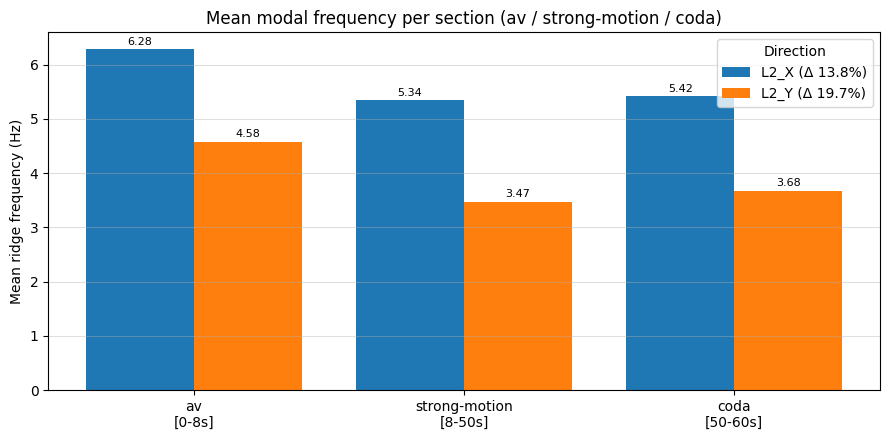

In [10]:
import pandas as pd

# Mean ridge frequency in each section (av | strong-motion | coda), per direction.
sections = list(zip(t_edges[:-1], t_edges[1:], band_labels))   # (t0, t1, label)
sec_labels = [f'{lab}\n[{b0}-{b1}s]' for b0, b1, lab in sections]

delta_col = 'Δ final coda-vs-initial av(%)'

rows = []
for name, (t_spec, f_ridge_s) in ridge_by_dir.items():
    row = {'Direction': name}
    for (b0, b1, _), lab in zip(sections, sec_labels):
        m = (t_spec >= b0) & (t_spec < b1)
        row[lab] = round(float(np.nanmean(f_ridge_s[m])), 3) if m.any() else np.nan
    # permanent frequency loss: final coda vs initial av (first vs last section)
    f_ini, f_fin = row[sec_labels[0]], row[sec_labels[-1]]
    row[delta_col] = round(-(f_fin - f_ini) / f_ini * 100, 2)
    rows.append(row)
df_ridge_mean = pd.DataFrame(rows).set_index('Direction')
print("Mean ridge frequency per section (Hz) + residual frequency loss (final coda vs initial av)")
display(df_ridge_mean)

# Grouped bar chart: one group per section, one bar per direction
mean_cols = sec_labels                                          # only the per-section means
x = np.arange(len(mean_cols))
w = 0.8 / len(df_ridge_mean)
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (name, vals) in enumerate(df_ridge_mean.iterrows()):
    bars = ax.bar(x + i * w, vals[mean_cols].values, width=w,
                  label=f"{name} (Δ {vals[delta_col]:.1f}%)")
    ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
ax.set_xticks(x + w * (len(df_ridge_mean) - 1) / 2)
ax.set_xticklabels(mean_cols)
ax.set_ylabel('Mean ridge frequency (Hz)')
ax.set_title('Mean modal frequency per section (av / strong-motion / coda)')
ax.grid(True, axis='y', alpha=0.4)
ax.legend(title='Direction')
plt.tight_layout()
plt.show()
